# Baseline: TF-IDF + SGD on the labeled DXF data

Goal: see how far a plain text-classification pipeline gets on the two domains we have labeled so far (Moscow and Regions). The features are character n-grams over `TYPE / LAYER / TEXT`; the classifier is a linear SGD with `class_weight='balanced'`.

Splits are group-aware by `Source_File` -- a single drawing never spans two splits. `l1` and `l2` are trained as independent heads.

If a row has no `l2` we keep it under a synthetic `no_l2` class (`l2_missing_policy='as_class'`).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, accuracy_score

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
rand_seed = 44

In [2]:
MSK_FILE     = Path('labeled_msk_df.csv')
REGIONS_FILE = Path('labeled_regions_df.csv')

msk_samples_num     = None
regions_samples_num = None

# Split settings
test_size = 0.2
val_size  = 0.1   # fraction of train+val

# Optional CV on the train split (off by default; turn on to sanity-check macro F1)
apply_cross_val   = False
cross_val_splits  = 3

# l2 missing handling: 'drop' or 'as_class'
l2_missing_policy = 'as_class'


REPORT_DIR = Path('baseline_reports')
REPORT_DIR.mkdir(exist_ok=True)

In [3]:
usecols = ['Source_File', 'Layer', 'Type', 'Text', 'l1', 'l2']

def load_df(path: Path, sample_n=None):
    print(f'Loading: {path}')
    df = pd.read_csv(path, usecols=usecols, low_memory=False)
    missing = [c for c in usecols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    for col in ['Source_File', 'Layer', 'Type', 'Text']:
        df[col] = df[col].fillna('').astype(str)

    if sample_n is not None and len(df) > sample_n:
        df = df.sample(n=sample_n, random_state=rand_seed).reset_index(drop=True)

    print(f'  rows={len(df):,}  unique Source_File={df["Source_File"].nunique():,}')
    return df

def report_missing(df: pd.DataFrame, name: str):
    l1_missing = df['l1'].isna().sum() + (df['l1'].astype(str).str.strip() == '').sum()
    l2_missing = df['l2'].isna().sum() + (df['l2'].astype(str).str.strip() == '').sum()
    print(f'\n{name} label coverage:')
    print(f'  l1 missing: {l1_missing:,} / {len(df):,} ({l1_missing / len(df) * 100:.2f}%)')
    print(f'  l2 missing: {l2_missing:,} / {len(df):,} ({l2_missing / len(df) * 100:.2f}%)')

In [4]:
def build_text_features(df: pd.DataFrame):

    return (
        'TYPE='  + df['Type'].astype(str)  + ' ' +
        'LAYER=' + df['Layer'].astype(str) + ' ' +
        'TEXT='  + df['Text'].astype(str)
    )

def split_train_val_test(X, y, groups):
    # Test split
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rand_seed)
    tv_idx, te_idx = next(gss.split(X, y, groups=groups))

    X_tv = X.iloc[tv_idx]; y_tv = y.iloc[tv_idx]; g_tv = groups.iloc[tv_idx]
    X_te = X.iloc[te_idx]; y_te = y.iloc[te_idx]; g_te = groups.iloc[te_idx]

    # Validation split inside train+val
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=rand_seed)
    tr_idx, val_idx = next(gss2.split(X_tv, y_tv, groups=g_tv))

    X_tr  = X_tv.iloc[tr_idx];  y_tr  = y_tv.iloc[tr_idx];  g_tr  = g_tv.iloc[tr_idx]
    X_val = X_tv.iloc[val_idx]; y_val = y_tv.iloc[val_idx]; g_val = g_tv.iloc[val_idx]

    return X_tr, y_tr, g_tr, X_val, y_val, g_val, X_te, y_te, g_te

In [5]:
def build_model():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            min_df=2,
            max_features=200_000,
        )),
        ('clf', SGDClassifier(
            loss='log_loss',
            alpha=1e-5,
            max_iter=20,
            tol=1e-3,
            n_jobs=-1,
            random_state=rand_seed,
            class_weight='balanced',
        )),
    ])

def prepare_target(df: pd.DataFrame, label_col: str):
    if label_col == 'l1':
        y = df['l1']
        mask = y.notna() & (y.astype(str).str.strip() != '')
        dropped = (~mask).sum()
        return df.loc[mask].copy(), y.loc[mask].astype(str), dropped

    if label_col == 'l2':
        y = df['l2']
        if l2_missing_policy == 'drop':
            mask = y.notna() & (y.astype(str).str.strip() != '')
            dropped = (~mask).sum()
            return df.loc[mask].copy(), y.loc[mask].astype(str), dropped
        if l2_missing_policy == 'as_class':
            y2 = y.fillna('no_l2').astype(str).str.strip()
            y2 = y2.replace('', 'no_l2')
            return df.copy(), y2, 0

    raise ValueError(f'Unsupported label_col: {label_col}')

def eval_split(y_true, y_pred, split_name):
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    print(f'{split_name:<6} | Macro-F1: {macro:.4f} | Weighted-F1: {weighted:.4f} | Acc: {acc:.4f}')
    return {'split': split_name, 'macro_f1': macro, 'weighted_f1': weighted, 'accuracy': acc}

def train_eval(df: pd.DataFrame, label_col: str, name: str):
    data, y, dropped = prepare_target(df, label_col)
    X_text = build_text_features(data)
    groups = data['Source_File']

    X_tr, y_tr, g_tr, X_val, y_val, _, X_te, y_te, _ = split_train_val_test(X_text, y, groups)

    print(f'\n==== {name} | {label_col} ====')
    print(f'Rows used: {len(data):,} | Dropped (empty label): {dropped:,} | Classes: {y.nunique()}')
    print(f'Train: {len(X_tr):,} | Val: {len(X_val):,} | Test: {len(X_te):,}')

    model = build_model()
    model.fit(X_tr, y_tr)

    rows = []
    rows.append({'domain': name, 'label': label_col, **eval_split(y_tr,  model.predict(X_tr),  'train')})
    rows.append({'domain': name, 'label': label_col, **eval_split(y_val, model.predict(X_val), 'val')})
    rows.append({'domain': name, 'label': label_col, **eval_split(y_te,  model.predict(X_te),  'test')})

    if apply_cross_val:
        print('\nGroupKFold CV on the train split:')
        gkf = GroupKFold(n_splits=cross_val_splits)
        macros = []
        for i, (ti, vi) in enumerate(gkf.split(X_tr, y_tr, groups=g_tr), 1):
            m = build_model().fit(X_tr.iloc[ti], y_tr.iloc[ti])
            macros.append(f1_score(y_tr.iloc[vi], m.predict(X_tr.iloc[vi]), average='macro', zero_division=0))
            print(f'  Fold {i}: macro F1 = {macros[-1]:.4f}')
        print(f'CV macro F1 mean={np.mean(macros):.4f}  std={np.std(macros):.4f}')

    return model, rows

## Moscow

In [6]:
msk_df = load_df(MSK_FILE, sample_n=msk_samples_num)
report_missing(msk_df, 'Moscow')

model_msk_l1, msk_l1_rows = train_eval(msk_df, 'l1', 'Moscow')
model_msk_l2, msk_l2_rows = train_eval(msk_df, 'l2', 'Moscow')

Loading: labeled_msk_df.csv
  rows=180,953  unique Source_File=370

Moscow label coverage:
  l1 missing: 0 / 180,953 (0.00%)
  l2 missing: 22,551 / 180,953 (12.46%)

==== Moscow | l1 ====
Rows used: 180,953 | Dropped (empty label): 0 | Classes: 12
Train: 104,953 | Val: 5,886 | Test: 70,114
train  | Macro-F1: 0.9753 | Weighted-F1: 0.9977 | Acc: 0.9977
val    | Macro-F1: 0.9008 | Weighted-F1: 0.9959 | Acc: 0.9958
test   | Macro-F1: 0.9601 | Weighted-F1: 0.9916 | Acc: 0.9915

==== Moscow | l2 ====
Rows used: 180,953 | Dropped (empty label): 0 | Classes: 32
Train: 104,953 | Val: 5,886 | Test: 70,114
train  | Macro-F1: 0.9742 | Weighted-F1: 0.9962 | Acc: 0.9962
val    | Macro-F1: 0.9191 | Weighted-F1: 0.9961 | Acc: 0.9961
test   | Macro-F1: 0.9219 | Weighted-F1: 0.9885 | Acc: 0.9881


## Regions

In [7]:
reg_df = load_df(REGIONS_FILE, sample_n=regions_samples_num)
report_missing(reg_df, 'Regions')

model_reg_l1, reg_l1_rows = train_eval(reg_df, 'l1', 'Regions')
model_reg_l2, reg_l2_rows = train_eval(reg_df, 'l2', 'Regions')

Loading: labeled_regions_df.csv
  rows=3,069,680  unique Source_File=146

Regions label coverage:
  l1 missing: 0 / 3,069,680 (0.00%)
  l2 missing: 0 / 3,069,680 (0.00%)

==== Regions | l1 ====
Rows used: 3,069,680 | Dropped (empty label): 0 | Classes: 11
Train: 2,390,049 | Val: 108,645 | Test: 570,986
train  | Macro-F1: 0.9588 | Weighted-F1: 0.9923 | Acc: 0.9922
val    | Macro-F1: 0.8921 | Weighted-F1: 0.9514 | Acc: 0.9527
test   | Macro-F1: 0.9681 | Weighted-F1: 0.9821 | Acc: 0.9822

==== Regions | l2 ====
Rows used: 3,069,680 | Dropped (empty label): 0 | Classes: 41
Train: 2,390,049 | Val: 108,645 | Test: 570,986
train  | Macro-F1: 0.9387 | Weighted-F1: 0.9929 | Acc: 0.9928
val    | Macro-F1: 0.8382 | Weighted-F1: 0.9701 | Acc: 0.9712
test   | Macro-F1: 0.8599 | Weighted-F1: 0.9744 | Acc: 0.9749


## Summary

Notes on how to read the table below:
- Compare macro F1 first -- accuracy and weighted F1 are dominated by the majority class.
- A big train-test gap usually points at label noise or domain shift between drawings.
- `l2` is finer-grained and sparser than `l1`, so a lower `l2` score is expected.

In [8]:
summary = pd.DataFrame(msk_l1_rows + msk_l2_rows + reg_l1_rows + reg_l2_rows).round(4)
out_csv = REPORT_DIR / 'baseline_metrics.csv'
summary.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}\n')
print(summary.to_string(index=False))

Saved: baseline_reports\baseline_metrics.csv

 domain label split  macro_f1  weighted_f1  accuracy
 Moscow    l1 train    0.9753       0.9977    0.9977
 Moscow    l1   val    0.9008       0.9959    0.9958
 Moscow    l1  test    0.9601       0.9916    0.9915
 Moscow    l2 train    0.9742       0.9962    0.9962
 Moscow    l2   val    0.9191       0.9961    0.9961
 Moscow    l2  test    0.9219       0.9885    0.9881
Regions    l1 train    0.9588       0.9923    0.9922
Regions    l1   val    0.8921       0.9514    0.9527
Regions    l1  test    0.9681       0.9821    0.9822
Regions    l2 train    0.9387       0.9929    0.9928
Regions    l2   val    0.8382       0.9701    0.9712
Regions    l2  test    0.8599       0.9744    0.9749


## Save trained models

Once the four classifiers are trained, dump them to `baseline_reports/models/`
using `joblib`. Reproducing the analysis later doesn't need the original
training pass — just `joblib.load` and the source DataFrames.

In [ ]:
import joblib

MODELS_DIR = REPORT_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

_to_save = [
    ('model_msk_l1', model_msk_l1),
    ('model_msk_l2', model_msk_l2),
    ('model_reg_l1', model_reg_l1),
    ('model_reg_l2', model_reg_l2),
]
for stem, clf in _to_save:
    path = MODELS_DIR / f'{stem}.joblib'
    joblib.dump(clf, path, compress=3)
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f'  saved: {path.name:<25s}  ({size_mb:>6.1f} MB)')

joblib.dump(
    {
        'msk_l1_rows': msk_l1_rows,
        'msk_l2_rows': msk_l2_rows,
        'reg_l1_rows': reg_l1_rows,
        'reg_l2_rows': reg_l2_rows,
    },
    MODELS_DIR / 'metric_rows.joblib',
)
print(f'\nAll artefacts under: {MODELS_DIR.resolve()}')

## Error analysis

The aggregate numbers above look very high — suspiciously high for a plain
TF-IDF + SGD baseline. The cells below dig deeper so the thesis can show:

1. **Confusion matrices** per (domain, label) — to see whether the residual
   errors concentrate in a few class pairs or are scattered.
2. **Per-class F1** — to see whether the macro-F1 is dragged down by a small
   handful of rare classes (which is common with class-balanced linear models).
3. **A misclassified-examples DataFrame** — joined back with `Source_File /
   Type / Layer / Text`, written to CSV, so failures can be eyeballed.
4. **Cross-domain transfer** — train on Moscow, evaluate on Regions and the
   other way around. A baseline that *truly* learnt the semantics should
   transfer at least partially; if it collapses, the high in-domain score is
   mostly memorising layer names.
5. **Feature ablation: Text-only vs Type+Layer+Text** — if Text alone scores
   far below the full baseline, then most of the signal was sitting in DXF
   layer names (which is realistic — designers name layers descriptively
   and that's effectively a leaked label). This is the most likely reason
   the numbers came out higher than expected.

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support, classification_report,
)

try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_style('whitegrid')
except Exception:
    HAS_SNS = False

plt.rcParams['figure.dpi'] = 90

MIS_DIR = REPORT_DIR / 'misclassified'
MIS_DIR.mkdir(exist_ok=True)

In [11]:
def _split_for_analysis(df, label_col):
    """Reproduce the train/val/test split used during training; keep the
    original row indices around so we can join back to Source_File/Layer/Text
    when looking at misclassified rows."""
    data, y, _ = prepare_target(df, label_col)
    X_text = build_text_features(data)
    groups = data['Source_File']
    Xtr, ytr, _gt, Xv, yv, _gv, Xte, yte, _gte = split_train_val_test(X_text, y, groups)
    return {
        'data': data,
        'X_test': Xte, 'y_test': yte,
        'X_val':  Xv,  'y_val':  yv,
        'X_train': Xtr, 'y_train': ytr,
    }

configs = [
    ('Moscow',  'l1', model_msk_l1, msk_df),
    ('Moscow',  'l2', model_msk_l2, msk_df),
    ('Regions', 'l1', model_reg_l1, reg_df),
    ('Regions', 'l2', model_reg_l2, reg_df),
]

eval_cache = {}
for name, label_col, model, df in configs:
    sp = _split_for_analysis(df, label_col)
    y_pred = model.predict(sp['X_test'])
    sp['y_pred'] = pd.Series(y_pred, index=sp['X_test'].index, name='pred')
    eval_cache[(name, label_col)] = sp
    print(f'{name:7s} / {label_col} | test rows = {len(sp["X_test"]):>9,d} | '
          f'classes seen = {len(model.classes_)}')

Moscow  / l1 | test rows =    70,114 | classes seen = 12
Moscow  / l2 | test rows =    70,114 | classes seen = 31
Regions / l1 | test rows =   570,986 | classes seen = 11
Regions / l2 | test rows =   570,986 | classes seen = 41


### Confusion matrices

Row-normalised: each cell is the fraction of *true* class examples that
ended up predicted as `column`. A perfect diagonal means the model never
confuses that class with anything else. Off-diagonal mass shows the actual
failure pattern.

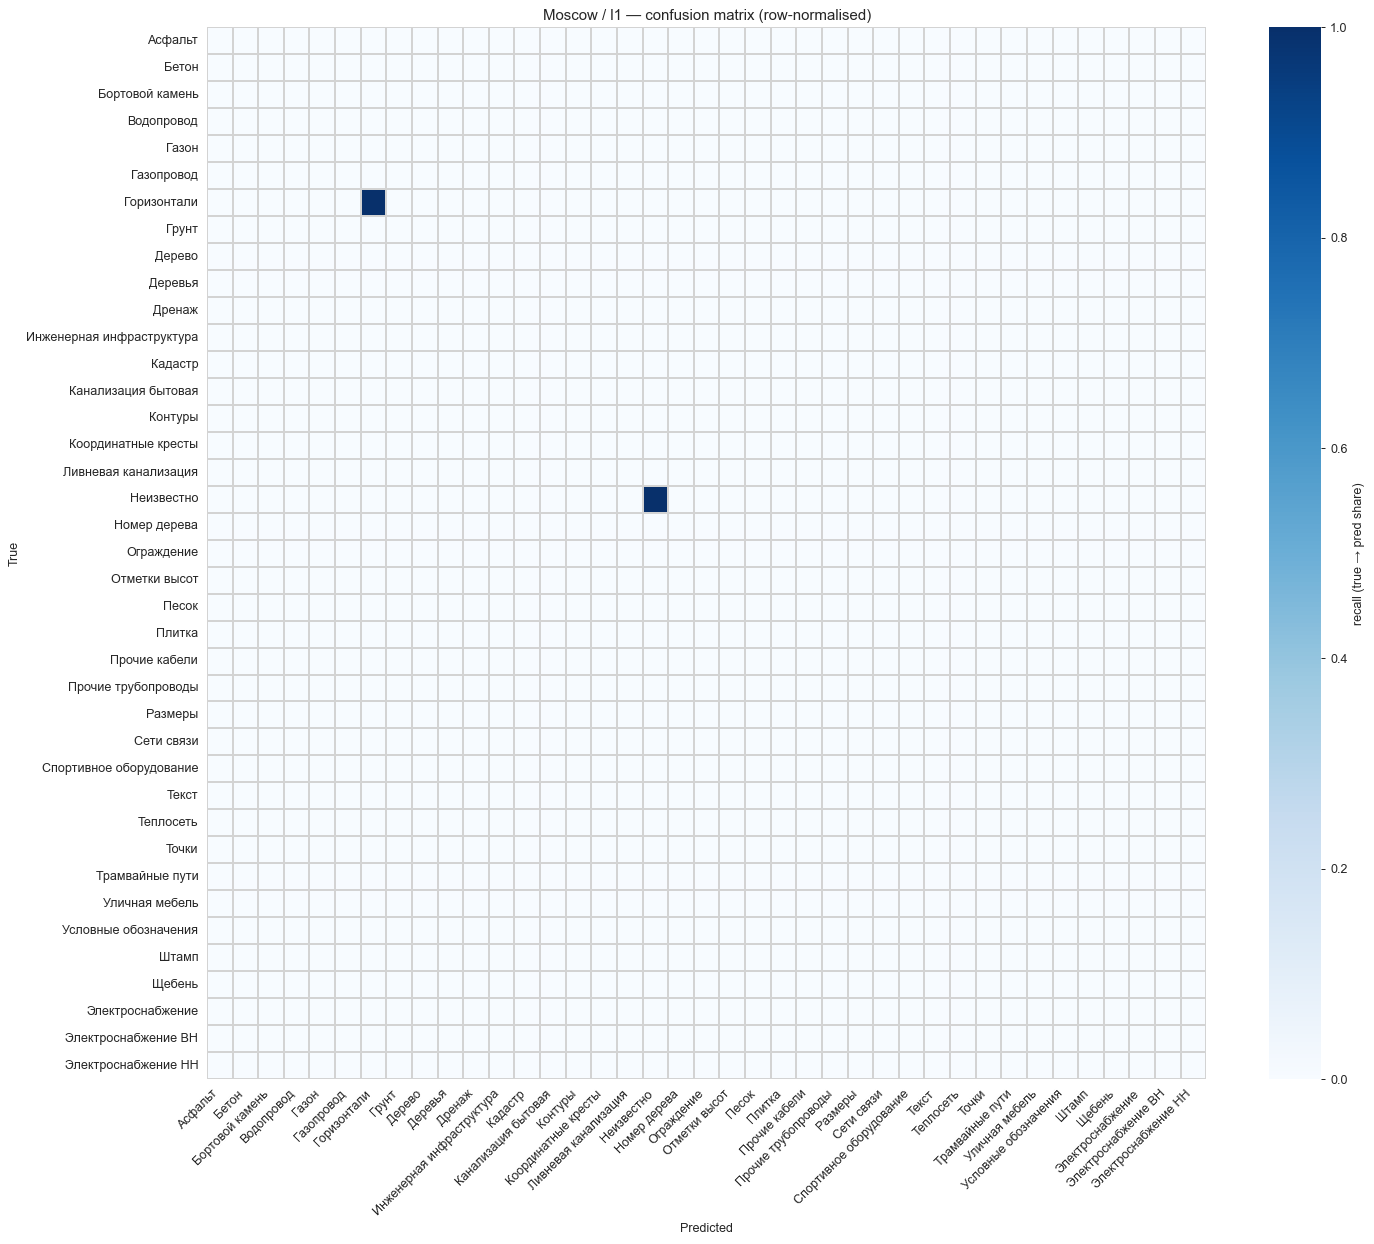

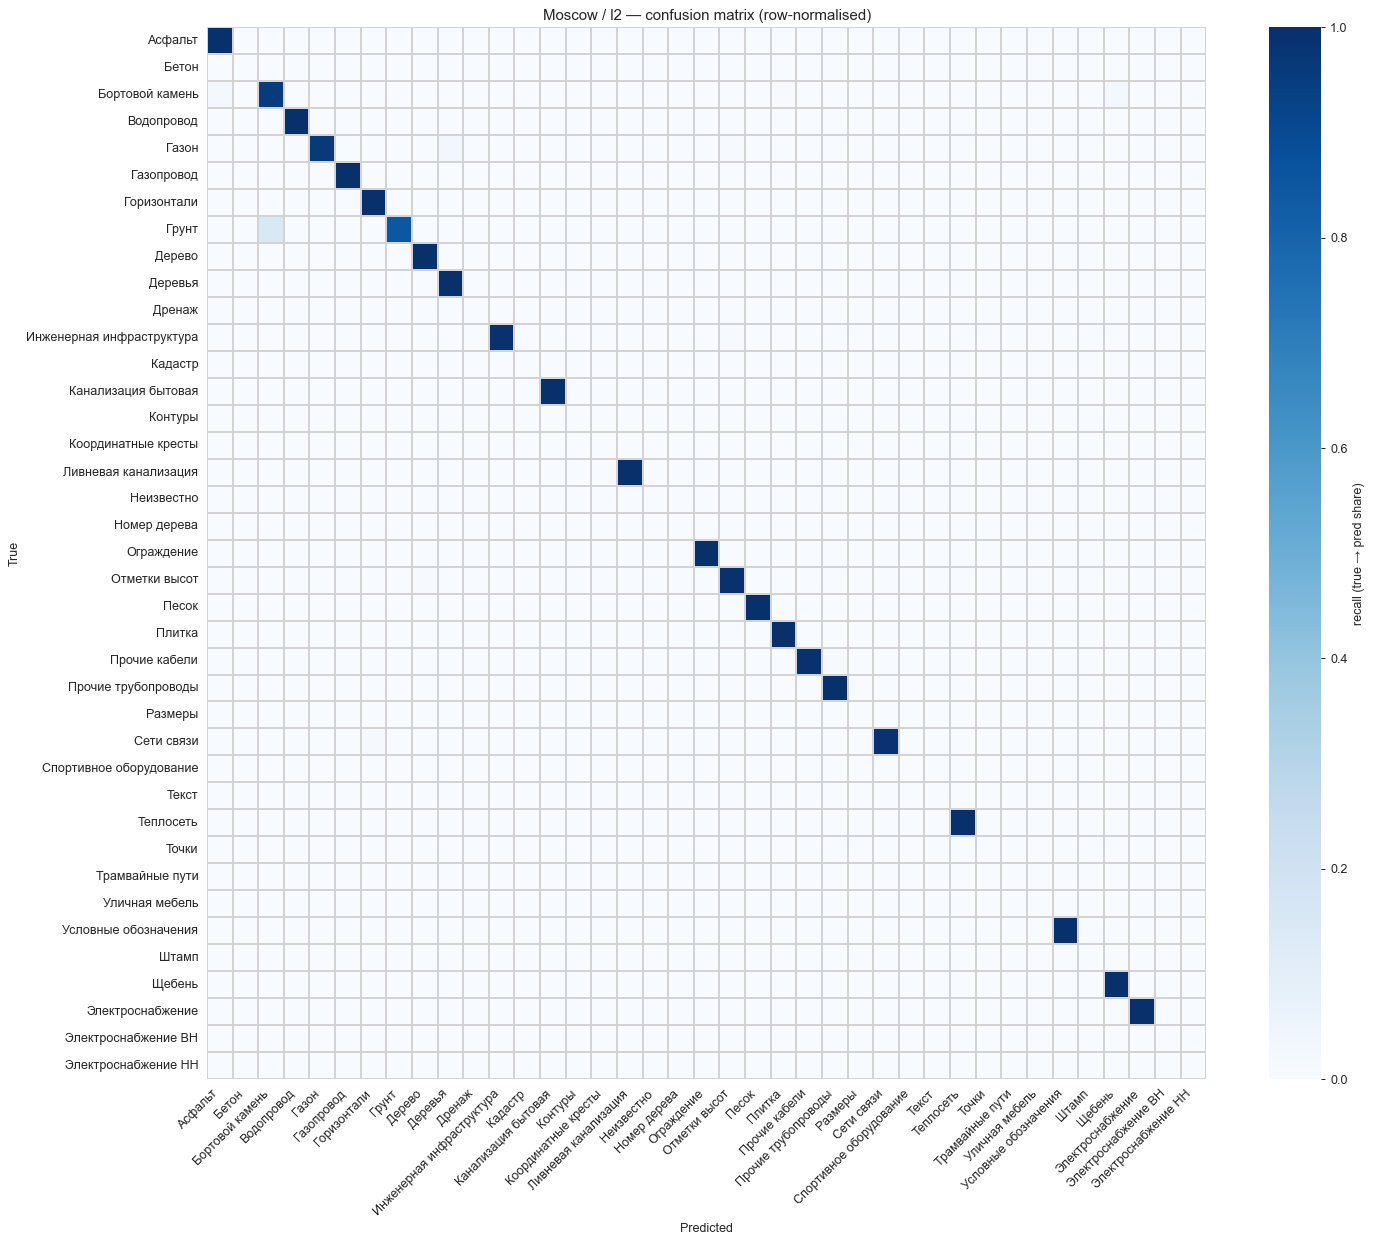

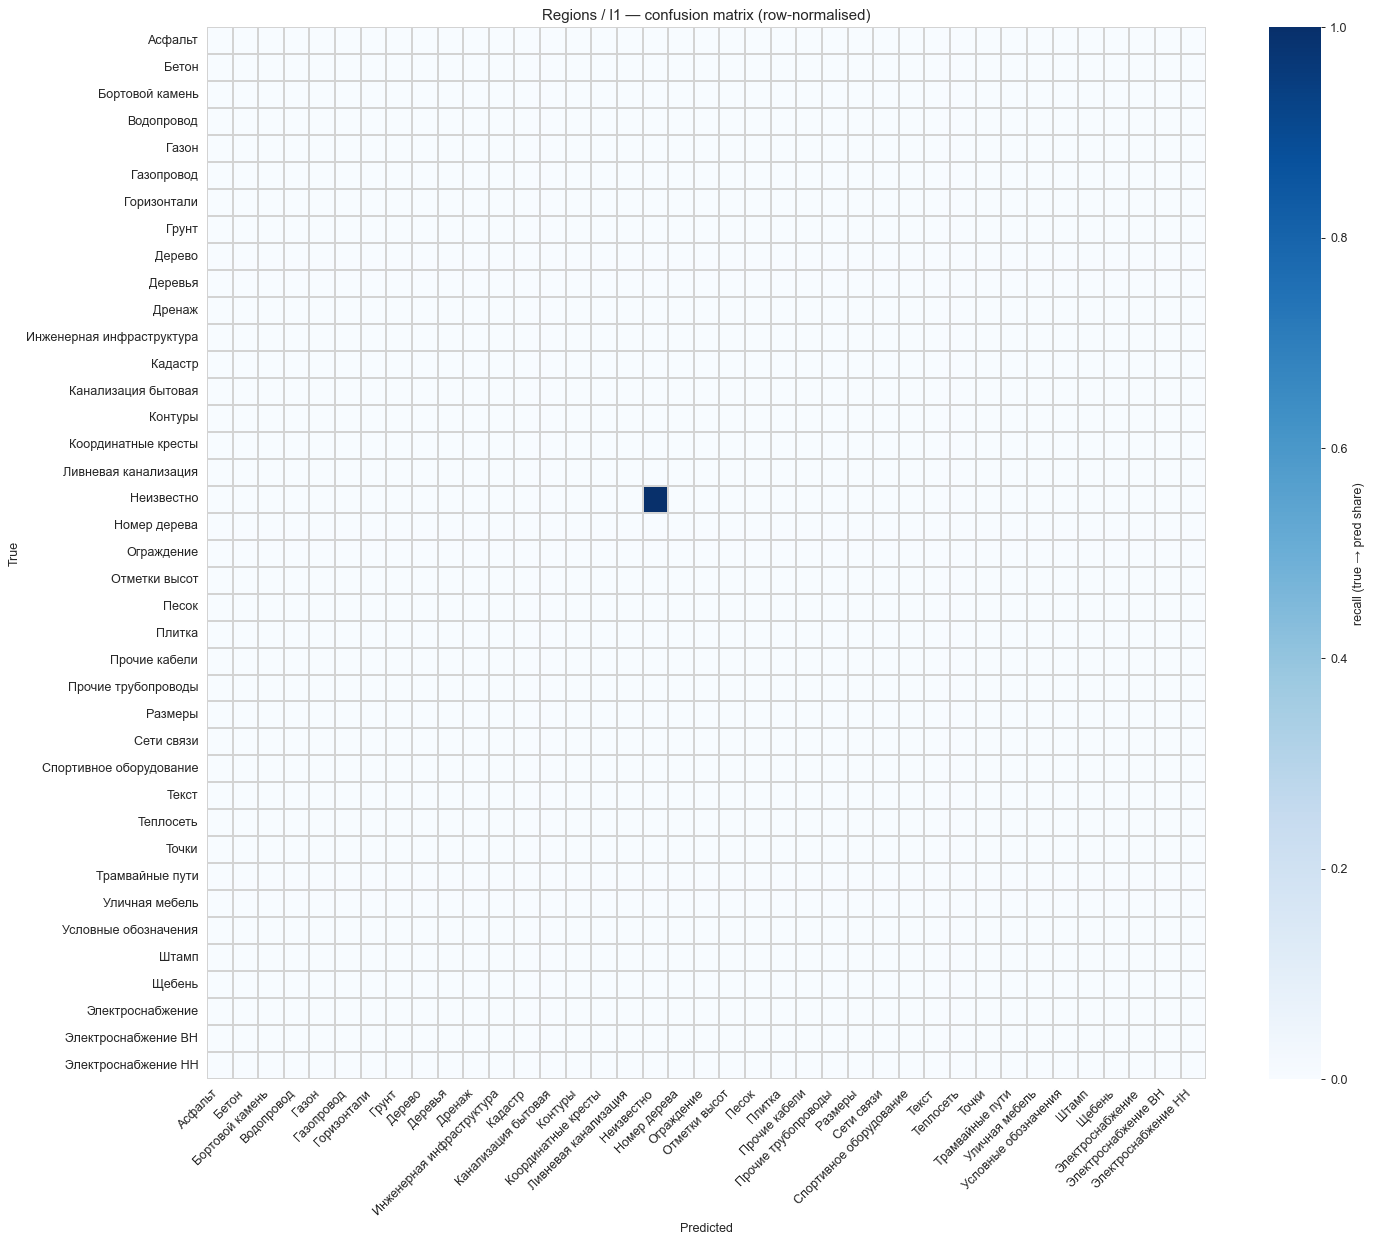

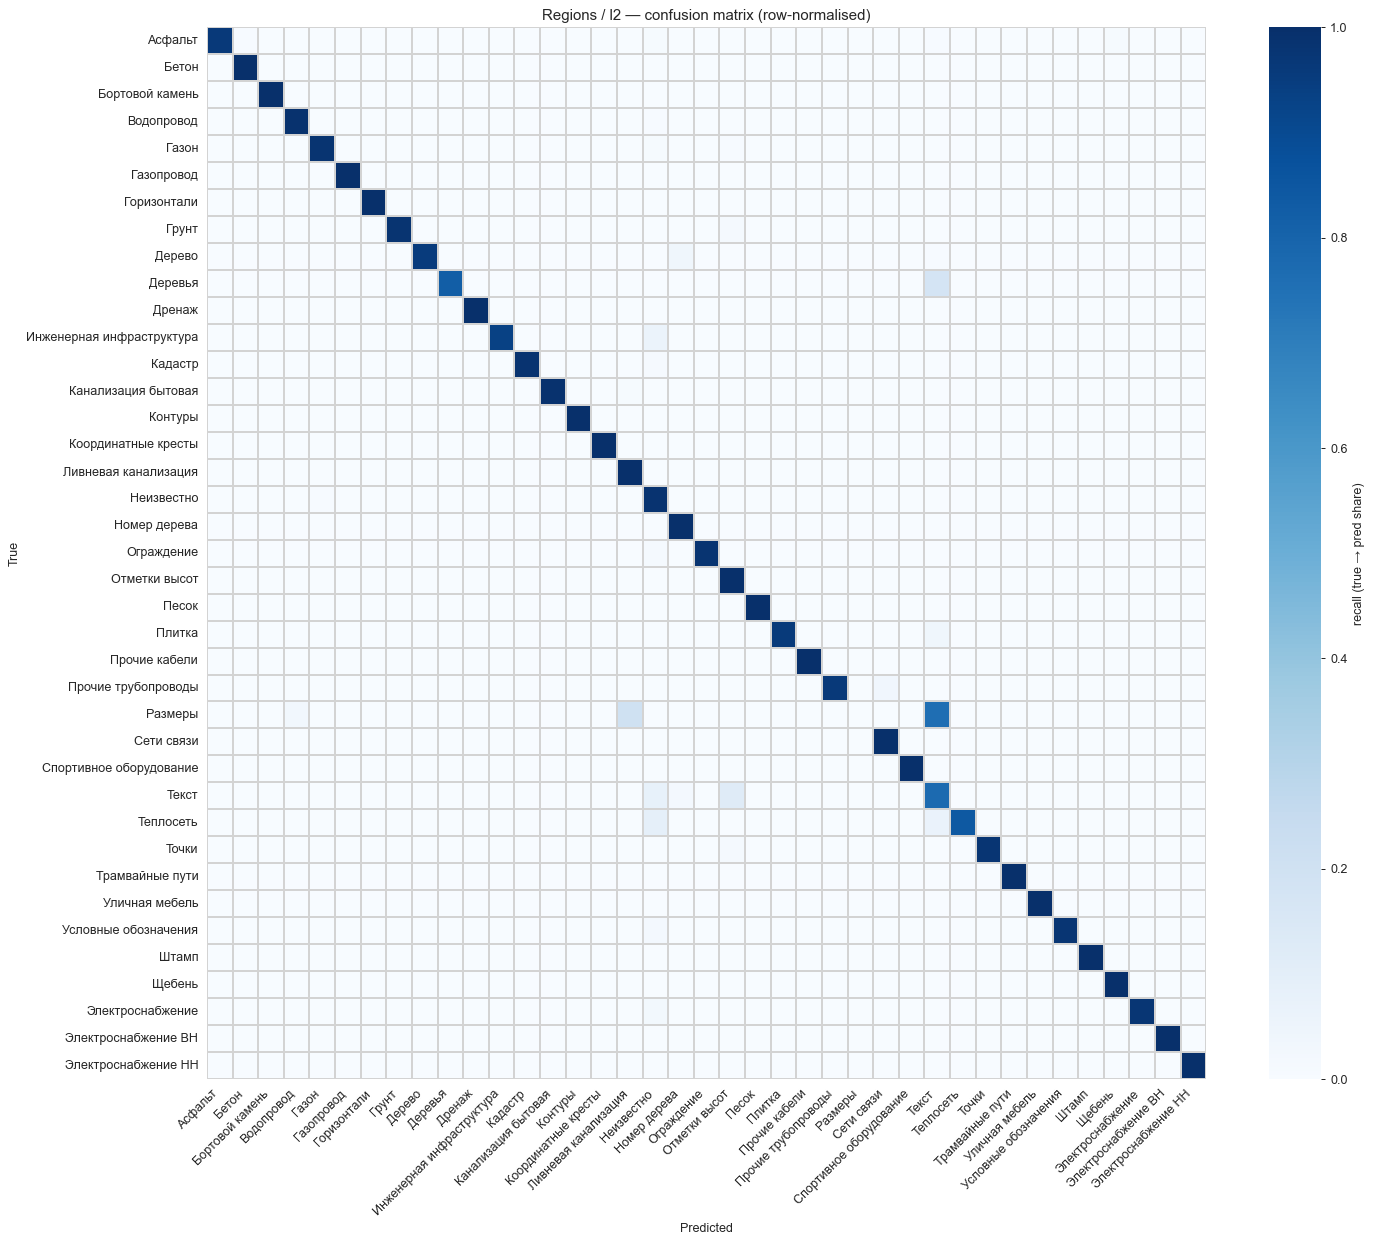

In [19]:
def _sort_classes(classes):
    try:
        return sorted(classes, key=lambda x: float(x))
    except (ValueError, TypeError):
        try:
            from natsort import natsorted
            return natsorted(classes)
        except ImportError:
            return sorted(classes)

def plot_confusion(name, label_col, sp):
    yt = sp['y_test']
    yp = sp['y_pred']
    cclasses = _sort_classes(set(yt.astype(str).unique()) | set(yp.astype(str).unique()))
    cm = confusion_matrix(yt.astype(str), yp.astype(str),
                            labels=classes, normalize='true')
    side = max(5.5, len(classes) * 0.42)
    fig, ax = plt.subplots(figsize=(side, side * 0.85))
    annotate = len(classes) <= 15
    if HAS_SNS:
        sns.heatmap(cm, xticklabels=classes, yticklabels=classes,
                     cmap='Blues', vmin=0, vmax=1,
                     annot=annotate, fmt='.2f',
                     cbar_kws={'label': 'recall (true → pred share)'},
                     square=False, linewidths=0.3, linecolor='lightgray',
                     ax=ax)
    else:
        im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha='right')
        ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
        plt.colorbar(im, ax=ax, label='recall (true → pred share)')
        if annotate:
            for i in range(len(classes)):
                for j in range(len(classes)):
                    ax.text(j, i, f'{cm[i,j]:.2f}',
                              ha='center', va='center',
                              color='black' if cm[i,j] < 0.5 else 'white',
                              fontsize=7)
    ax.set_title(f'{name} / {label_col} — confusion matrix (row-normalised)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for (name, label_col), sp in eval_cache.items():
    plot_confusion(name, label_col, sp)

### Per-class F1 + support

A weighted/macro F1 of 0.9 is consistent both with "everything works
uniformly well" and with "a few rare classes are wrecking macro but the
mass of common classes is fine". The per-class bar chart disambiguates.
Each bar is annotated with class support (number of test rows) so it's
obvious whether a low F1 sits on hundreds of rows or just three.

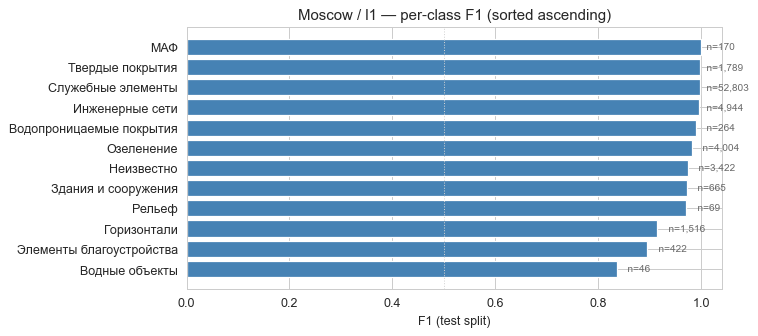

,class,precision,recall,f1,support
0,Водные объекты,0.7188,1.0000,0.8364,46
1,Элементы благоустройства,0.8371,0.9621,0.8953,422
2,Горизонтали,0.9019,0.9281,0.9148,1516
3,Рельеф,0.9710,0.9710,0.9710,69
4,Здания и сооружения,0.9984,0.9459,0.9714,665
5,Неизвестно,0.9602,0.9871,0.9735,3422
6,Озеленение,0.9891,0.9753,0.9821,4004
7,Водопроницаемые покрытия,0.9813,0.9962,0.9887,264
8,Инженерные сети,0.9943,0.9947,0.9945,4944
9,Служебные элементы,0.9978,0.9952,0.9965,52803


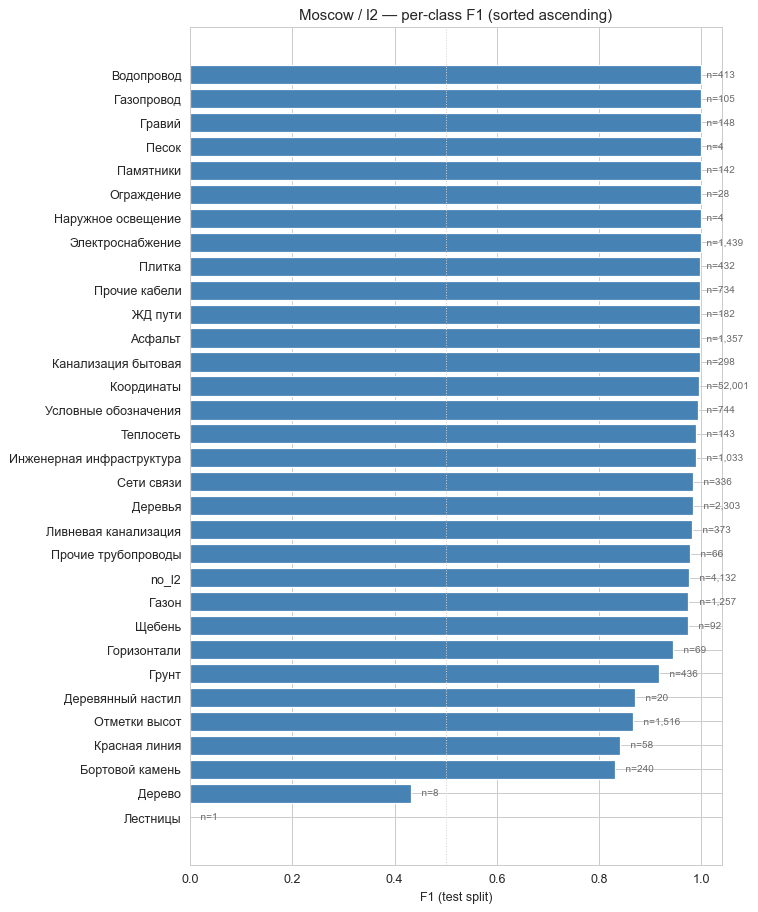

,class,precision,recall,f1,support
0,Лестницы,0.0000,0.0000,0.0000,1
1,Дерево,0.2759,1.0000,0.4324,8
2,Бортовой камень,0.7363,0.9542,0.8312,240
3,Красная линия,0.7250,1.0000,0.8406,58
4,Отметки высот,0.8119,0.9281,0.8661,1516
5,Деревянный настил,0.7692,1.0000,0.8696,20
6,Грунт,0.9946,0.8509,0.9172,436
7,Горизонтали,0.9178,0.9710,0.9437,69
8,Щебень,0.9485,1.0000,0.9735,92
9,Газон,0.9926,0.9570,0.9745,1257


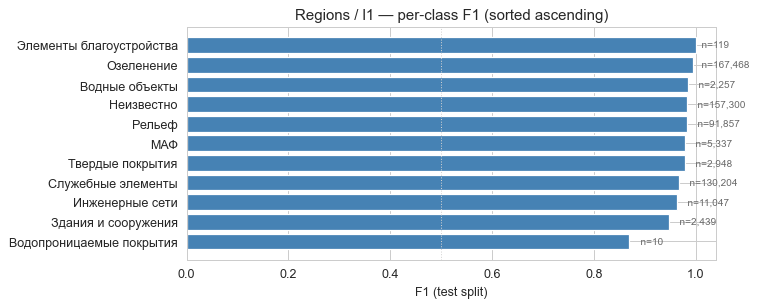

,class,precision,recall,f1,support
0,Водопроницаемые покрытия,0.7692,1.0000,0.8696,10
1,Здания и сооружения,0.9027,0.9967,0.9474,2439
2,Инженерные сети,0.9514,0.9742,0.9627,11047
3,Служебные элементы,0.9948,0.9415,0.9674,130204
4,Твердые покрытия,0.9697,0.9874,0.9785,2948
5,МАФ,0.9615,0.9972,0.9790,5337
6,Рельеф,0.9657,0.9995,0.9823,91857
7,Неизвестно,0.9789,0.9875,0.9832,157300
8,Водные объекты,0.9794,0.9894,0.9844,2257
9,Озеленение,0.9897,0.9991,0.9944,167468


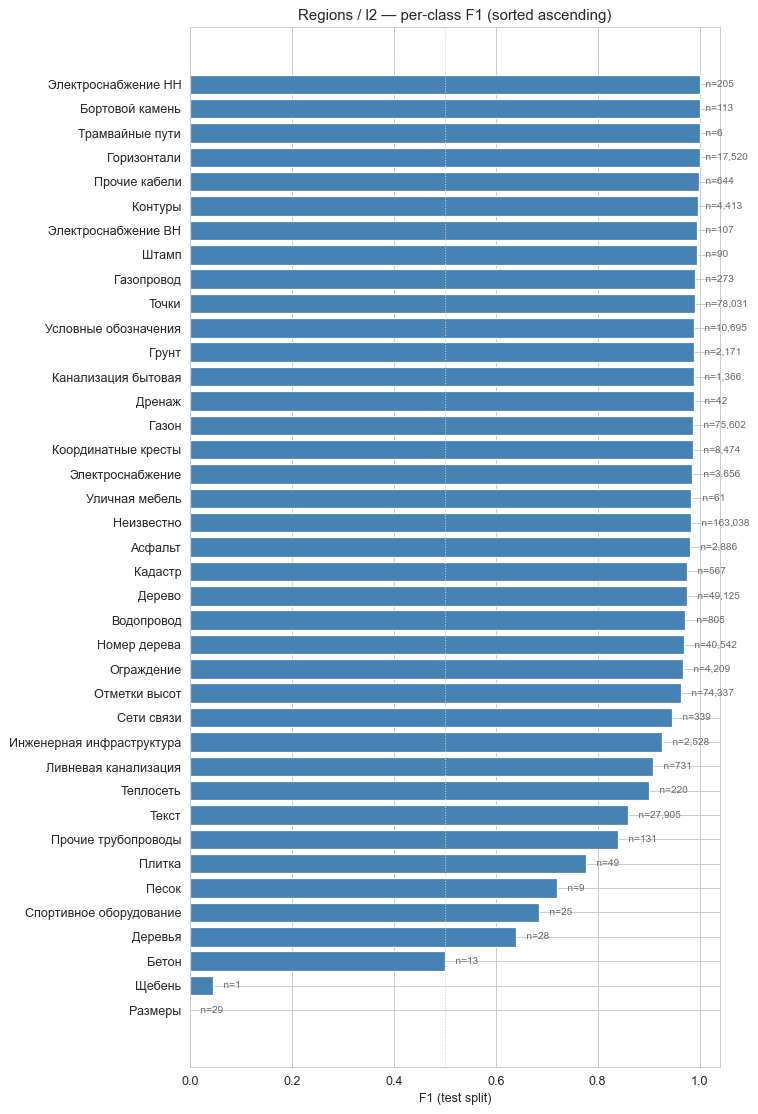

,class,precision,recall,f1,support
0,Размеры,0.0000,0.0000,0.0000,29
1,Щебень,0.0233,1.0000,0.0455,1
2,Бетон,0.3333,1.0000,0.5000,13
3,Деревья,0.5227,0.8214,0.6389,28
4,Спортивное оборудование,0.5208,1.0000,0.6849,25
5,Песок,0.5625,1.0000,0.7200,9
6,Плитка,0.6528,0.9592,0.7769,49
7,Прочие трубопроводы,0.7456,0.9618,0.8400,131
8,Текст,0.9617,0.7758,0.8588,27905
9,Теплосеть,0.9686,0.8409,0.9002,220


In [13]:
per_class_tables = {}

for (name, label_col), sp in eval_cache.items():
    yt = sp['y_test'].astype(str)
    yp = sp['y_pred'].astype(str)
    classes = sorted(yt.unique())
    p, r, f, s = precision_recall_fscore_support(
        yt, yp, labels=classes, zero_division=0
    )
    tbl = pd.DataFrame({
        'class':     classes,
        'precision': p.round(4),
        'recall':    r.round(4),
        'f1':        f.round(4),
        'support':   s.astype(int),
    }).sort_values('f1', ascending=True)
    per_class_tables[(name, label_col)] = tbl
    tbl.to_csv(REPORT_DIR / f'perclass_{name}_{label_col}.csv', index=False)

    height = max(3.0, len(tbl) * 0.32)
    fig, ax = plt.subplots(figsize=(8.5, height))
    bars = ax.barh(tbl['class'], tbl['f1'], color='steelblue')
    ax.set_xlim(0, 1.04)
    ax.set_xlabel('F1 (test split)')
    ax.set_title(f'{name} / {label_col} — per-class F1 (sorted ascending)')
    for bar, f1v, sup in zip(bars, tbl['f1'], tbl['support']):
        ax.text(min(f1v + 0.01, 1.0),
                bar.get_y() + bar.get_height() / 2,
                f'  n={sup:,}',
                va='center', fontsize=8, color='dimgray')
    ax.axvline(0.5, color='lightgray', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    print()
    display(tbl.reset_index(drop=True))

### Misclassified examples


In [14]:
# Build a single "misclassified" DataFrame across all four configs.
misclass_parts = []
for (name, label_col), sp in eval_cache.items():
    yt = sp['y_test'].astype(str)
    yp = sp['y_pred'].astype(str)
    wrong = yt.values != yp.values
    test_idx = yt.index[wrong]

    rows = sp['data'].loc[test_idx, ['Source_File', 'Type', 'Layer', 'Text']].copy()
    rows['true']   = yt.loc[test_idx].values
    rows['pred']   = yp.loc[test_idx].values
    rows['domain'] = name
    rows['label']  = label_col
    rows = rows[['domain', 'label', 'Source_File', 'Type', 'Layer', 'Text',
                  'true', 'pred']]

    out = MIS_DIR / f'misclassified_{name}_{label_col}.csv'
    rows.to_csv(out, index=False)
    n_total = len(sp['y_test'])
    print(f'{name:7s} / {label_col} | misclassified: {len(rows):>7,d} / {n_total:,} '
          f'({len(rows)/n_total*100:.2f}%)   →   {out.name}')
    misclass_parts.append(rows)

misclass_df = pd.concat(misclass_parts, ignore_index=True)
misclass_df.to_csv(MIS_DIR / 'misclassified_all.csv', index=False)
print(f'\nCombined CSV: {MIS_DIR / "misclassified_all.csv"}   '
      f'({len(misclass_df):,} rows)')
print('\nHead of the combined misclassified DataFrame:')
display(misclass_df.head(20))

Moscow  / l1 | misclassified:     593 / 70,114 (0.85%)   →   misclassified_Moscow_l1.csv
Moscow  / l2 | misclassified:     832 / 70,114 (1.19%)   →   misclassified_Moscow_l2.csv
Regions / l1 | misclassified:  10,147 / 570,986 (1.78%)   →   misclassified_Regions_l1.csv
Regions / l2 | misclassified:  14,353 / 570,986 (2.51%)   →   misclassified_Regions_l2.csv

Combined CSV: baseline_reports\misclassified\misclassified_all.csv   (25,925 rows)

Head of the combined misclassified DataFrame:


,domain,label,Source_File,Type,Layer,Text,true,pred
0,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,1А,Здания и сооружения,Горизонтали
1,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,31/22,Здания и сооружения,Горизонтали
2,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,31/22,Здания и сооружения,Горизонтали
3,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,58С.17,Здания и сооружения,Горизонтали
4,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,31/22,Здания и сооружения,Горизонтали
5,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,25/33,Здания и сооружения,Горизонтали
6,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,25/33,Здания и сооружения,Горизонтали
7,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,25/33,Здания и сооружения,Горизонтали
8,Moscow,l1,output(1)_3_ДЖКХпр-23_02382tp.dxf,TEXT,Номер дома,31/22,Здания и сооружения,Горизонтали
9,Moscow,l1,output(1-2)_3_ДЖКХпр-24_00875up.dxf,TEXT,Общий коллектор,183.70в.колл.,Инженерные сети,Неизвестно


In [15]:
print('Top-10 confusion pairs per (domain, label):\n')
for (name, label_col), sp in eval_cache.items():
    err = pd.DataFrame({
        'true': sp['y_test'].astype(str).values,
        'pred': sp['y_pred'].astype(str).values,
    })
    err = err[err['true'] != err['pred']]
    top = (err.groupby(['true', 'pred'])
                .size()
                .reset_index(name='count')
                .sort_values('count', ascending=False)
                .head(10)
                .reset_index(drop=True))
    print(f'── {name} / {label_col} ──')
    print(top.to_string(index=False))
    print()

Top-10 confusion pairs per (domain, label):

── Moscow / l1 ──
               true                     pred  count
 Служебные элементы               Неизвестно    113
        Горизонтали       Служебные элементы    100
 Служебные элементы              Горизонтали     96
         Озеленение Элементы благоустройства     66
Здания и сооружения              Горизонтали     28
         Неизвестно               Озеленение     24
 Служебные элементы          Инженерные сети     24
    Инженерные сети               Неизвестно     16
         Озеленение              Горизонтали     14
         Озеленение           Водные объекты     13

── Moscow / l2 ──
                     true                 pred  count
               Координаты        Отметки высот    272
               Координаты                no_l2    114
            Отметки высот           Координаты    100
                    Грунт      Бортовой камень     65
                    Газон              Деревья     44
                    no

### Cross-domain transfer (unseen-distribution test)



In [16]:
# Cross-domain: train on src_df, evaluate on dst_df.
def cross_domain_eval(src_name, src_model, dst_name, dst_df, label_col):
    data, y_true, _ = prepare_target(dst_df, label_col)
    X = build_text_features(data)
    y_pred = pd.Series(src_model.predict(X), index=y_true.index, name='pred')

    seen = set(src_model.classes_)
    mask_in_both = y_true.isin(seen)
    n_kept = int(mask_in_both.sum())
    n_total = int(len(y_true))
    coverage = n_kept / n_total if n_total else 0.0

    if n_kept == 0:
        macro = weighted = acc = float('nan')
    else:
        yt = y_true[mask_in_both].astype(str)
        yp = y_pred[mask_in_both].astype(str)
        macro    = f1_score(yt, yp, average='macro',    zero_division=0)
        weighted = f1_score(yt, yp, average='weighted', zero_division=0)
        acc      = accuracy_score(yt, yp)

    print(f'{src_name:7s} → {dst_name:7s} ({label_col}) | '
          f'rows kept {n_kept:>9,d} / {n_total:,} ({coverage*100:5.1f}%)  '
          f'macro {macro:.4f}  weighted {weighted:.4f}  acc {acc:.4f}')
    return {
        'src': src_name, 'dst': dst_name, 'label': label_col,
        'rows_kept': n_kept, 'rows_total': n_total,
        'coverage': round(coverage, 4),
        'macro_f1': round(macro, 4),
        'weighted_f1': round(weighted, 4),
        'accuracy': round(acc, 4),
    }

cd_rows = []
print('Cross-domain transfer:')
cd_rows.append(cross_domain_eval('Moscow',  model_msk_l1, 'Regions', reg_df, 'l1'))
cd_rows.append(cross_domain_eval('Regions', model_reg_l1, 'Moscow',  msk_df, 'l1'))
cd_rows.append(cross_domain_eval('Moscow',  model_msk_l2, 'Regions', reg_df, 'l2'))
cd_rows.append(cross_domain_eval('Regions', model_reg_l2, 'Moscow',  msk_df, 'l2'))

cross_df = pd.DataFrame(cd_rows)
cross_df.to_csv(REPORT_DIR / 'cross_domain_metrics.csv', index=False)
print(f'\nSaved: {REPORT_DIR / "cross_domain_metrics.csv"}')
display(cross_df)

Cross-domain transfer:
Moscow  → Regions (l1) | rows kept 3,069,680 / 3,069,680 (100.0%)  macro 0.1379  weighted 0.0635  acc 0.0704
Regions → Moscow  (l1) | rows kept   177,470 / 180,953 ( 98.1%)  macro 0.3430  weighted 0.1855  acc 0.2088
Moscow  → Regions (l2) | rows kept 1,354,133 / 3,069,680 ( 44.1%)  macro 0.3106  weighted 0.1652  acc 0.1323
Regions → Moscow  (l2) | rows kept    44,656 / 180,953 ( 24.7%)  macro 0.4999  weighted 0.6917  acc 0.6560

Saved: baseline_reports\cross_domain_metrics.csv


,src,dst,label,rows_kept,rows_total,coverage,macro_f1,weighted_f1,accuracy
0,Moscow,Regions,l1,3069680,3069680,1.0000,0.1379,0.0635,0.0704
1,Regions,Moscow,l1,177470,180953,0.9808,0.3430,0.1855,0.2088
2,Moscow,Regions,l2,1354133,3069680,0.4411,0.3106,0.1652,0.1323
3,Regions,Moscow,l2,44656,180953,0.2468,0.4999,0.6917,0.6560


## Load saved models 



In [10]:
import joblib

MODELS_DIR = REPORT_DIR / 'models'

def _load(stem):
    path = MODELS_DIR / f'{stem}.joblib'
    if not path.exists():
        raise FileNotFoundError(
            f'{path} not found. Re-run the training cells (Moscow + Regions) '
            'and the Save section above to produce it.'
        )
    print(f'  loading {path.name} ...')
    return joblib.load(path)

# 1) Source DataFrames — cheap, just CSV reads.
msk_df = load_df(MSK_FILE, sample_n=msk_samples_num)
report_missing(msk_df, 'Moscow')
reg_df = load_df(REGIONS_FILE, sample_n=regions_samples_num)
report_missing(reg_df, 'Regions')

# 2) The four classifiers.
model_msk_l1 = _load('model_msk_l1')
model_msk_l2 = _load('model_msk_l2')
model_reg_l1 = _load('model_reg_l1')
model_reg_l2 = _load('model_reg_l2')

# 3) Cached per-split metric rows (so the summary DataFrame still builds).
_metric_cache = joblib.load(MODELS_DIR / 'metric_rows.joblib')
msk_l1_rows = _metric_cache['msk_l1_rows']
msk_l2_rows = _metric_cache['msk_l2_rows']
reg_l1_rows = _metric_cache['reg_l1_rows']
reg_l2_rows = _metric_cache['reg_l2_rows']


Loading: labeled_msk_df.csv
  rows=180,953  unique Source_File=370

Moscow label coverage:
  l1 missing: 0 / 180,953 (0.00%)
  l2 missing: 22,551 / 180,953 (12.46%)
Loading: labeled_regions_df.csv
  rows=3,069,680  unique Source_File=146

Regions label coverage:
  l1 missing: 0 / 3,069,680 (0.00%)
  l2 missing: 0 / 3,069,680 (0.00%)
  loading model_msk_l1.joblib ...
  loading model_msk_l2.joblib ...
  loading model_reg_l1.joblib ...
  loading model_reg_l2.joblib ...


### Feature ablation — Text-only vs Type+Layer+Text


Feature ablation (Text-only vs Type+Layer+Text):

Moscow  / l1 | rows= 180,953 | full=0.9601 | text-only=0.9163 | Δ=+0.0438


c:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Moscow  / l2 | rows= 180,953 | full=0.9219 | text-only=0.7880 | Δ=+0.1339


c:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Regions / l1 | rows= 200,000 | full=0.8986 | text-only=0.2549 | Δ=+0.6437


c:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Regions / l2 | rows= 200,000 | full=0.8509 | text-only=0.1974 | Δ=+0.6535

Saved: baseline_reports\feature_ablation.csv


,domain,label,rows_used,full_macro_f1,text_only_macro_f1,delta_macro_f1
0,Moscow,l1,180953,0.9601,0.9163,0.0438
1,Moscow,l2,180953,0.9219,0.7880,0.1339
2,Regions,l1,200000,0.8986,0.2549,0.6437
3,Regions,l2,200000,0.8509,0.1974,0.6535


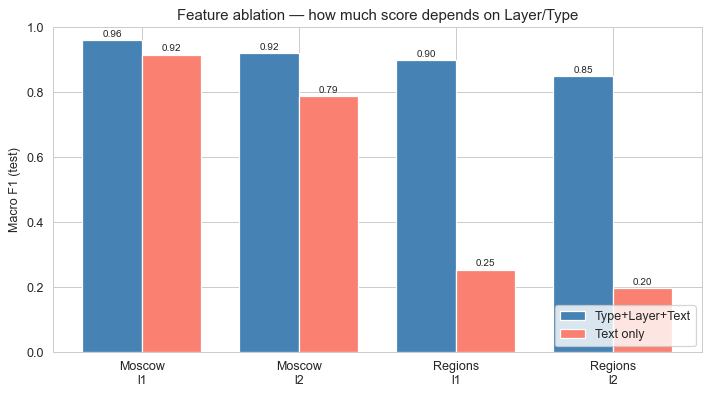

In [18]:
# Run / skip the ablation (trains 8 models).
RUN_ABLATION = True

# downsample Regions for speed.
ablation_msk_n     = None
ablation_regions_n = 200_000

def _ablation_features(df, mode):
    if mode == 'full':
        return build_text_features(df)
    if mode == 'text_only':
        return df['Text'].astype(str)
    raise ValueError(mode)

def ablate(df, name, label_col):
    if name == 'Regions' and ablation_regions_n and len(df) > ablation_regions_n:
        df = df.sample(n=ablation_regions_n, random_state=rand_seed).reset_index(drop=True)
    if name == 'Moscow' and ablation_msk_n and len(df) > ablation_msk_n:
        df = df.sample(n=ablation_msk_n, random_state=rand_seed).reset_index(drop=True)

    data, y, _ = prepare_target(df, label_col)
    groups = data['Source_File']

    out = {'domain': name, 'label': label_col, 'rows_used': int(len(data))}
    for mode, label in [('full', 'full_macro_f1'),
                         ('text_only', 'text_only_macro_f1')]:
        X = _ablation_features(data, mode)
        Xtr, ytr, _, _, _, _, Xte, yte, _ = split_train_val_test(X, y, groups)
        m = build_model().fit(Xtr, ytr)
        out[label] = round(
            f1_score(yte, m.predict(Xte), average='macro', zero_division=0),
            4,
        )
    out['delta_macro_f1'] = round(out['full_macro_f1'] - out['text_only_macro_f1'], 4)
    print(f'{name:7s} / {label_col} | rows={out["rows_used"]:>8,d} | '
          f'full={out["full_macro_f1"]:.4f} | text-only={out["text_only_macro_f1"]:.4f} | '
          f'Δ={out["delta_macro_f1"]:+.4f}')
    return out

if RUN_ABLATION:
    abl_rows = []
    print('Feature ablation (Text-only vs Type+Layer+Text):\n')
    abl_rows.append(ablate(msk_df,  'Moscow',  'l1'))
    abl_rows.append(ablate(msk_df,  'Moscow',  'l2'))
    abl_rows.append(ablate(reg_df,  'Regions', 'l1'))
    abl_rows.append(ablate(reg_df,  'Regions', 'l2'))

    abl_df = pd.DataFrame(abl_rows)
    abl_df.to_csv(REPORT_DIR / 'feature_ablation.csv', index=False)
    print(f'\nSaved: {REPORT_DIR / "feature_ablation.csv"}')
    display(abl_df)


    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(abl_df))
    width = 0.38
    ax.bar(x - width/2, abl_df['full_macro_f1'],      width,
           label='Type+Layer+Text', color='steelblue')
    ax.bar(x + width/2, abl_df['text_only_macro_f1'], width,
           label='Text only',       color='salmon')
    labels = [f'{r.domain}\n{r.label}' for r in abl_df.itertuples()]
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Macro F1 (test)')
    ax.set_title('Feature ablation — how much score depends on Layer/Type')
    ax.legend(loc='lower right')
    for i, (a, b) in enumerate(zip(abl_df['full_macro_f1'],
                                     abl_df['text_only_macro_f1'])):
        ax.text(i - width/2, a + 0.01, f'{a:.2f}', ha='center', fontsize=8)
        ax.text(i + width/2, b + 0.01, f'{b:.2f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('RUN_ABLATION=False — skipping feature ablation.')